# K-Nearest Neighbors (KNN) Classifier from Scratch

This notebook implements the KNN classification algorithm from scratch using NumPy and Matplotlib.

## Mathematical Foundations
KNN is a distance-based, non-parametric algorithm. For a query point $x$:
1. Calculate distance $d(x, x^{(i)})$ between $x$ and all training samples $x^{(i)}$. We use **Euclidean Distance**:
   $$d(x, x^{(i)}) = \sqrt{\sum_{j=1}^{d} (x_j - x^{(i)}_j)^2}$$
2. Find the $K$ training samples with the smallest distances.
3. Return the class label that is most common among these $K$ neighbors (majority vote).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## Generate Synthetic Classification Data

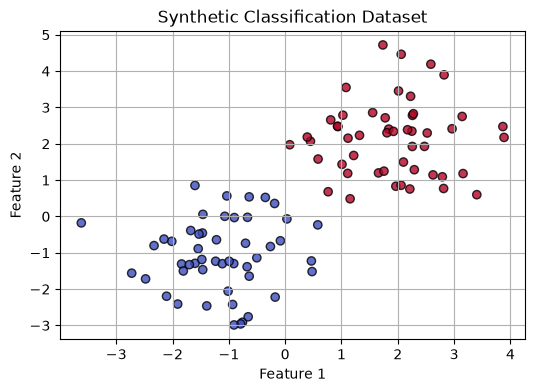

In [2]:
# Generate 2 clusters of data
c1 = np.random.randn(50, 2) + np.array([-1, -1])
c2 = np.random.randn(50, 2) + np.array([2, 2])
X = np.vstack([c1, c2])
y = np.array([0]*50 + [1]*50)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.8)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Synthetic Classification Dataset')
plt.grid(True)
plt.show()

## KNN Implementation

In [3]:
class KNNFromScratch:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None
        
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        
    def predict(self, X):
        return np.array([self._predict_single(x) for x in X])
        
    def _predict_single(self, x):
        # Calculate Euclidean distances to all training points
        distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
        
        # Get the indices of the K smallest distances
        k_indices = np.argsort(distances)[:self.k]
        
        # Get the labels of those K neighbors
        k_nearest_labels = self.y_train[k_indices]
        
        # Majority vote
        counts = np.bincount(k_nearest_labels)
        return np.argmax(counts)

## Evaluate Model & Plot Decision Boundary

Training Accuracy: 100.00%


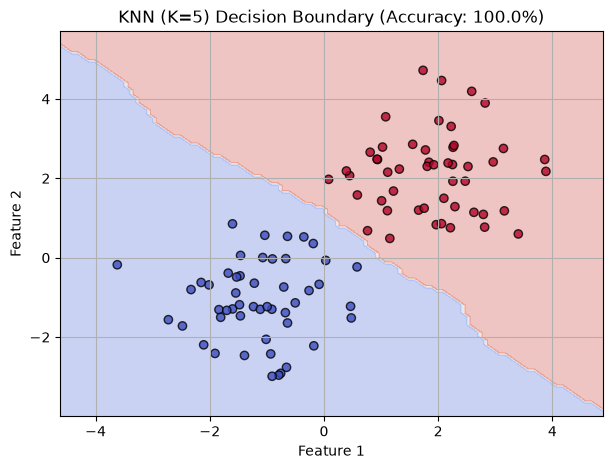

In [4]:
model = KNNFromScratch(k=5)
model.fit(X, y)

y_pred = model.predict(X)
accuracy = np.mean(y_pred == y)
print(f"Training Accuracy: {accuracy * 100:.2f}%")

# Grid for boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.8)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'KNN (K=5) Decision Boundary (Accuracy: {accuracy*100:.1f}%)')
plt.grid(True)
plt.show()